# Phase-4A — Step B: Train a Kidney Segmentation Model (Masking for All Patients)
You asked for a model that **learns kidney masking** and then produces masks for **all patients**.

This notebook trains a lightweight **U-Net** on your manual polygon masks (`dmsa.json`) and then runs inference on the full dataset.

## Output
- Predicted masks saved as PNG (256×256):
  - `0 = background`, `1 = left kidney`, `2 = right kidney`

## Important (matches your rules)
- Uses your CSV column names exactly (NO renaming)
- Matches masks to images by CSV `LINK` basename
- Patient-wise split (no leakage)
- Label-consistent flip (if image flips, left/right mask channels swap)

Start by setting paths in **CELL 2**.


In [4]:
# CELL 1 — FULL REPLACEMENT
# Imports (finalcodev6–v8 style)
import os, random, json
import numpy as np
import pandas as pd

import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt


In [5]:
# CELL 2 — FULL REPLACEMENT
# Global config (DO NOT rename CSV columns)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# --- Paths (YOU MUST SET THESE) ---
CSV_PATH   = r"D:\Base\dmsa_dataset.csv"   # e.g. r"C:\Users\Rashed Fahim\Desktop\Thesis1\DMSA\DATA SUPERVISED.csv"
IMAGE_ROOT = r"D:\Base\Data"   # folder that contains the images referenced by LINK
JSON_PATH  = r"D:\base\dmsa.json"   # path to dmsa.json (polygon annotations)

# --- CSV columns (EXACT NAMES — DO NOT CHANGE) ---
COL_PATIENT = "PATIENT NAME"
COL_LINK    = "LINK"
COL_VIEW    = "VIEW"
COL_COUNT   = "Kidney COUNT"
COL_ANAT    = "ANATOMY"
COL_POS     = "POSITION"
COL_SCAR    = "SCAR"
COL_UPL     = "CORTICAL UPTAKE LEFT"
COL_UPR     = "CORTICAL UPTAKE RIGHT"
COL_SIZE_L  = "SIZE LEFT"
COL_SIZE_R  = "SIZE RIGHT"

# --- Segmentation settings ---
IMG_H, IMG_W = 256, 256
NUM_CLASSES = 3  # 0=bg, 1=left, 2=right

# Train settings (small dataset)
EPOCHS = 35
BATCH  = 8
LR     = 2e-4
WD     = 1e-4

# Windows stability
NUM_WORKERS = 0
PIN_MEMORY  = torch.cuda.is_available()

# Output
OUT_DIR = r"./phase4a_seg_outputs"   # relative folder is OK
BEST_CKPT = os.path.join(OUT_DIR, "best_unet.pt")

# Augmentation knobs
AUG_FLIP_P = 0.5
AUG_ROT_DEG = 8.0

os.makedirs(OUT_DIR, exist_ok=True)

print("Configured OUT_DIR:", OUT_DIR)


CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti
Configured OUT_DIR: ./phase4a_seg_outputs


In [6]:
# CELL 3 — FULL REPLACEMENT
# Sanity checks + load CSV + add basename helper
assert CSV_PATH != r"", "Set CSV_PATH in CELL 2"
assert IMAGE_ROOT != r"", "Set IMAGE_ROOT in CELL 2"
assert JSON_PATH != r"", "Set JSON_PATH (dmsa.json) in CELL 2"

assert os.path.exists(CSV_PATH), f"CSV not found: {CSV_PATH}"
assert os.path.exists(IMAGE_ROOT), f"IMAGE_ROOT not found: {IMAGE_ROOT}"
assert os.path.exists(JSON_PATH), f"JSON not found: {JSON_PATH}"

df = pd.read_csv(CSV_PATH)

required = [COL_PATIENT, COL_LINK]
for c in required:
    assert c in df.columns, f"Missing column in CSV: {c}"

df["_LINK_NORM"] = df[COL_LINK].astype(str).str.replace('\\', '/', regex=False)
df["_BASENAME"]  = df["_LINK_NORM"].apply(lambda x: os.path.basename(x))

print("Rows:", len(df))
print("Unique basenames:", df["_BASENAME"].nunique())
print("Example basenames:", df["_BASENAME"].head(5).tolist())


Rows: 2294
Unique basenames: 2294
Example basenames: ['A_RAHMAN_6_MONTHS.jpeg', 'A_RAHMAN_6_MONTHS_1.jpeg', 'A_RAHMAN_6_MONTHS_2.jpeg', 'ABDUL_ALIM_1_MONTHS.jpeg', 'ABDUL_ALIM_1_MONTHS_1.jpeg']


In [7]:
# CELL 4 — FULL REPLACEMENT
# Load dmsa.json into mask_db: basename -> list of polygon regions with label left/right

with open(JSON_PATH, "r", encoding="utf-8") as f:
    anno = json.load(f)

def _norm_label(x):
    if x is None:
        return None
    s = str(x).strip().lower()
    if s in ["l", "left"]:
        return "left"
    if s in ["r", "right"]:
        return "right"
    return s

def _extract_regions_from_entry(entry):
    regions = []
    # VGG-style
    if isinstance(entry, dict) and "regions" in entry:
        rs = entry["regions"]
        if isinstance(rs, dict):
            rs = list(rs.values())
        if isinstance(rs, list):
            for reg in rs:
                if not isinstance(reg, dict):
                    continue
                sa = reg.get("shape_attributes", {})
                ra = reg.get("region_attributes", {})
                if sa.get("name") != "polygon":
                    continue
                xs = sa.get("all_points_x", [])
                ys = sa.get("all_points_y", [])
                lab = ra.get("label", ra.get("side", ra.get("kidney", ra.get("name", None))))
                lab = _norm_label(lab)
                regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    # List format
    if isinstance(entry, list):
        for reg in entry:
            if not isinstance(reg, dict):
                continue
            xs = reg.get("all_points_x") or reg.get("xs") or []
            ys = reg.get("all_points_y") or reg.get("ys") or []
            lab = _norm_label(reg.get("label", reg.get("side", reg.get("name", None))))
            regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    # Custom key
    if isinstance(entry, dict) and "polygons" in entry:
        for reg in entry["polygons"]:
            xs = reg.get("x", reg.get("xs", []))
            ys = reg.get("y", reg.get("ys", []))
            lab = _norm_label(reg.get("label", reg.get("side", None)))
            regions.append({"label": lab, "xs": xs, "ys": ys})
        return regions

    return regions

mask_db = {}
if isinstance(anno, dict):
    for k, v in anno.items():
        base = os.path.basename(str(k).replace('\\','/'))
        regs = _extract_regions_from_entry(v)
        if len(regs) > 0:
            mask_db[base] = regs
elif isinstance(anno, list):
    for item in anno:
        if not isinstance(item, dict):
            continue
        fname = item.get("filename", item.get("file", item.get("image", None)))
        if fname is None:
            continue
        base = os.path.basename(str(fname).replace('\\','/'))
        regs = _extract_regions_from_entry(item)
        if len(regs) > 0:
            mask_db[base] = regs

print("Mask files in JSON:", len(mask_db))
print("Example keys:", list(mask_db.keys())[:5])

df["_HAS_MASK"] = df["_BASENAME"].apply(lambda b: b in mask_db)
print("CSV rows with mask:", int(df["_HAS_MASK"].sum()))


Mask files in JSON: 2294
Example keys: ['SARIBA_8YRS.jpeg', 'SARIBA_8YRS_1.jpeg', 'SARIBA_8YRS_2.jpeg', 'SAUDA_10YRS.jpeg', 'SAUDA_10YRS_1.jpeg']
CSV rows with mask: 2294


In [8]:
# CELL 5 — FULL REPLACEMENT
# Helpers: image loading + polygon->mask + LR consistency checks

def resolve_image_path_from_csv_row(row):
    # Use CSV LINK (preferred)
    rel = row["_LINK_NORM"]
    cand = os.path.join(IMAGE_ROOT, rel)
    if os.path.exists(cand):
        return cand

    # Fallbacks: basename under IMAGE_ROOT or walk
    base = row["_BASENAME"]
    cand1 = os.path.join(IMAGE_ROOT, base)
    if os.path.exists(cand1):
        return cand1

    for root, _, files in os.walk(IMAGE_ROOT):
        if base in files:
            return os.path.join(root, base)

    raise FileNotFoundError(f"Image not found for basename: {base}")

def load_image_gray256(path):
    img = Image.open(path).convert("L").resize((IMG_W, IMG_H), resample=Image.BILINEAR)
    return np.array(img, dtype=np.uint8)

def polygons_to_mask(regions):
    m = np.zeros((IMG_H, IMG_W), dtype=np.uint8)  # 0 bg, 1 left, 2 right
    for reg in regions:
        lab = _norm_label(reg.get("label"))
        xs = reg.get("xs", [])
        ys = reg.get("ys", [])
        if lab not in ["left","right"]:
            continue
        if xs is None or ys is None:
            continue
        if len(xs) < 3 or len(ys) < 3:
            continue
        pts = np.stack([np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)], axis=1)
        pts[:,0] = np.clip(pts[:,0], 0, IMG_W-1)
        pts[:,1] = np.clip(pts[:,1], 0, IMG_H-1)
        pts_i = pts.astype(np.int32).reshape((-1,1,2))
        cls = 1 if lab=="left" else 2
        cv2.fillPoly(m, [pts_i], cls)
    return m

def mask_centroid(mask, cls):
    ys, xs = np.where(mask == cls)
    if len(xs) == 0:
        return None
    return float(xs.mean()), float(ys.mean())

def lr_order_flags(mask):
    cL = mask_centroid(mask, 1)
    cR = mask_centroid(mask, 2)
    flags=[]
    if cL is None: flags.append("NO_LEFT")
    if cR is None: flags.append("NO_RIGHT")
    if cL is not None and cR is not None and not (cL[0] < cR[0]):
        flags.append("LR_X_ORDER_WRONG")
    return flags, cL, cR


In [9]:
# CELL 6 — FULL REPLACEMENT
# Build the segmentation dataframe (unique image basenames with masks)

seg_df = df[df["_HAS_MASK"]].copy()

# Keep one row per basename for segmentation (avoids duplicates from CSV if any)
seg_df = seg_df.drop_duplicates(subset=["_BASENAME"]).reset_index(drop=True)

print("Unique images with masks:", len(seg_df))
print(seg_df[["_BASENAME", COL_PATIENT, COL_VIEW, COL_ANAT, COL_POS, COL_COUNT]].head(5))


Unique images with masks: 2294
                    _BASENAME PATIENT NAME VIEW ANATOMY            POSITION  \
0      A_RAHMAN_6_MONTHS.jpeg     A RAHMAN    P  NORMAL  NORMAL RENAL FOSSA   
1    A_RAHMAN_6_MONTHS_1.jpeg     A RAHMAN  LPO  NORMAL  NORMAL RENAL FOSSA   
2    A_RAHMAN_6_MONTHS_2.jpeg     A RAHMAN  RPO  NORMAL  NORMAL RENAL FOSSA   
3    ABDUL_ALIM_1_MONTHS.jpeg   ABDUL ALIM    P  NORMAL  NORMAL RENAL FOSSA   
4  ABDUL_ALIM_1_MONTHS_1.jpeg   ABDUL ALIM  LPO  NORMAL  NORMAL RENAL FOSSA   

   Kidney COUNT  
0             2  
1             2  
2             2  
3             2  
4             2  


In [10]:
# CELL 7 — FULL REPLACEMENT
# Patient-wise split for segmentation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(seg_df, groups=seg_df[COL_PATIENT].astype(str)))

train_seg = seg_df.iloc[train_idx].reset_index(drop=True)
val_seg   = seg_df.iloc[val_idx].reset_index(drop=True)

print("Train images:", len(train_seg))
print("Val images:", len(val_seg))
print("Train patients:", train_seg[COL_PATIENT].nunique(), "Val patients:", val_seg[COL_PATIENT].nunique())


Train images: 1805
Val images: 489
Train patients: 474 Val patients: 119


In [11]:
# CELL 8 — FULL REPLACEMENT
# Dataset with label-consistent flip (swap left/right classes on flip)

class SegDataset(Dataset):
    def __init__(self, sdf, train=True):
        self.sdf = sdf.reset_index(drop=True)
        self.train = train

    def __len__(self):
        return len(self.sdf)

    def __getitem__(self, idx):
        row = self.sdf.iloc[idx]
        base = row["_BASENAME"]
        path = resolve_image_path_from_csv_row(row)

        img = load_image_gray256(path)  # uint8 [0..255]
        mask = polygons_to_mask(mask_db[base])  # uint8 {0,1,2}

        # augmentations (moderate)
        if self.train:
            # horizontal flip with label swap (left<->right)
            if random.random() < AUG_FLIP_P:
                img = img[:, ::-1].copy()
                mask = mask[:, ::-1].copy()
                # swap class ids 1 and 2
                tmp = mask.copy()
                mask[tmp == 1] = 2
                mask[tmp == 2] = 1

            # small rotation (same on img and mask)
            if AUG_ROT_DEG > 0:
                ang = random.uniform(-AUG_ROT_DEG, AUG_ROT_DEG)
                M = cv2.getRotationMatrix2D((IMG_W/2, IMG_H/2), ang, 1.0)
                img = cv2.warpAffine(img, M, (IMG_W, IMG_H), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
                mask = cv2.warpAffine(mask, M, (IMG_W, IMG_H), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        # normalize image to float32
        x = img.astype(np.float32) / 255.0
        x = (x - x.mean()) / (x.std() + 1e-6)
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # 1xHxW

        y = torch.tensor(mask.astype(np.int64), dtype=torch.long)  # HxW (0..2)
        return x, y, base

train_ds = SegDataset(train_seg, train=True)
val_ds   = SegDataset(val_seg, train=False)

print("Dataset OK:", len(train_ds), len(val_ds))


Dataset OK: 1805 489


In [12]:
# CELL 9 — FULL REPLACEMENT
# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

xb, yb, bb = next(iter(train_loader))
print("Batch x:", xb.shape, xb.dtype, "Batch y:", yb.shape, yb.dtype)
print("Unique classes in batch y:", torch.unique(yb).tolist())


Batch x: torch.Size([8, 1, 256, 256]) torch.float32 Batch y: torch.Size([8, 256, 256]) torch.int64
Unique classes in batch y: [0, 1, 2]


In [13]:
# CELL 10 — FULL REPLACEMENT
# Model: Small U-Net (lightweight, 1-channel, 3-class)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=1, n_classes=3, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = ConvBlock(base*2, base)

        self.outc = nn.Conv2d(base, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        d3 = self.up3(e4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.outc(d1)

model = UNetSmall(in_ch=1, n_classes=NUM_CLASSES, base=32).to(device)
print(model.__class__.__name__)


UNetSmall


In [14]:
# CELL 11 — FULL REPLACEMENT
# Loss: CrossEntropy + Dice (medically safer for class imbalance)

def dice_per_class(pred, target, cls, eps=1e-6):
    # pred, target: HxW int
    p = (pred == cls).astype(np.uint8)
    t = (target == cls).astype(np.uint8)
    inter = (p & t).sum()
    denom = p.sum() + t.sum()
    return float((2*inter + eps) / (denom + eps))

def soft_dice_loss(logits, target, eps=1e-6):
    # logits: BxCxHxW, target: BxHxW
    probs = torch.softmax(logits, dim=1)
    target_1h = F.one_hot(target, NUM_CLASSES).permute(0,3,1,2).float()  # BxCxHxW

    dims = (0,2,3)
    inter = torch.sum(probs * target_1h, dims)
    denom = torch.sum(probs + target_1h, dims)
    dice = (2*inter + eps) / (denom + eps)
    # ignore background in loss weighting (focus on kidneys)
    dice_fg = dice[1:].mean()
    return 1.0 - dice_fg

ce_loss = nn.CrossEntropyLoss()

def total_loss(logits, target):
    return ce_loss(logits, target) + 0.7 * soft_dice_loss(logits, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("Loss+optimizer ready.")


Loss+optimizer ready.


In [15]:
# CELL 12 — FULL REPLACEMENT
# Train / Validate

def run_eval(model, loader):
    model.eval()
    dices_L=[]
    dices_R=[]
    with torch.no_grad():
        for x, y, _base in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            gt   = y.cpu().numpy()
            for i in range(pred.shape[0]):
                dices_L.append(dice_per_class(pred[i], gt[i], 1))
                dices_R.append(dice_per_class(pred[i], gt[i], 2))
    return float(np.mean(dices_L)), float(np.mean(dices_R)), float(np.mean(dices_L + dices_R))

best_score = -1.0

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    nb = 0

    for x, y, _base in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = total_loss(logits, y)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss became NaN/Inf. Stop and report this batch.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running += float(loss.item())
        nb += 1

    scheduler.step()

    val_dL, val_dR, val_dAvg = run_eval(model, val_loader)
    train_loss = running / max(1, nb)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_dice_L={val_dL:.4f} val_dice_R={val_dR:.4f} val_dice_avg={val_dAvg:.4f}")

    if val_dAvg > best_score:
        best_score = val_dAvg
        torch.save(model.state_dict(), BEST_CKPT)
        print(f"  ✅ Saved best checkpoint: {BEST_CKPT}")

print("Best val dice avg:", best_score)


Epoch 01 | train_loss=1.2408 | val_dice_L=0.5422 val_dice_R=0.2403 val_dice_avg=0.3912
  ✅ Saved best checkpoint: ./phase4a_seg_outputs\best_unet.pt
Epoch 02 | train_loss=0.8225 | val_dice_L=0.7220 val_dice_R=0.5522 val_dice_avg=0.6371
  ✅ Saved best checkpoint: ./phase4a_seg_outputs\best_unet.pt
Epoch 03 | train_loss=0.6014 | val_dice_L=0.7326 val_dice_R=0.6623 val_dice_avg=0.6975
  ✅ Saved best checkpoint: ./phase4a_seg_outputs\best_unet.pt
Epoch 04 | train_loss=0.4198 | val_dice_L=0.6115 val_dice_R=0.5815 val_dice_avg=0.5965
Epoch 05 | train_loss=0.3062 | val_dice_L=0.7607 val_dice_R=0.6708 val_dice_avg=0.7158
  ✅ Saved best checkpoint: ./phase4a_seg_outputs\best_unet.pt
Epoch 06 | train_loss=0.2625 | val_dice_L=0.6843 val_dice_R=0.6428 val_dice_avg=0.6636
Epoch 07 | train_loss=0.2418 | val_dice_L=0.7485 val_dice_R=0.7012 val_dice_avg=0.7248
  ✅ Saved best checkpoint: ./phase4a_seg_outputs\best_unet.pt
Epoch 08 | train_loss=0.2199 | val_dice_L=0.7640 val_dice_R=0.7027 val_dice_avg=0

C:\Users\User\AppData\Local\Temp\ipykernel_2332\990193025.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_CKPT, map_location=device

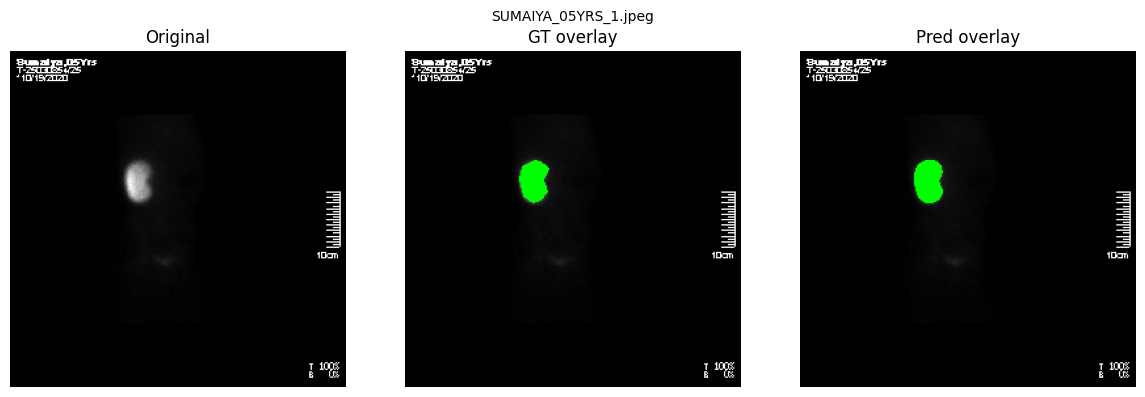

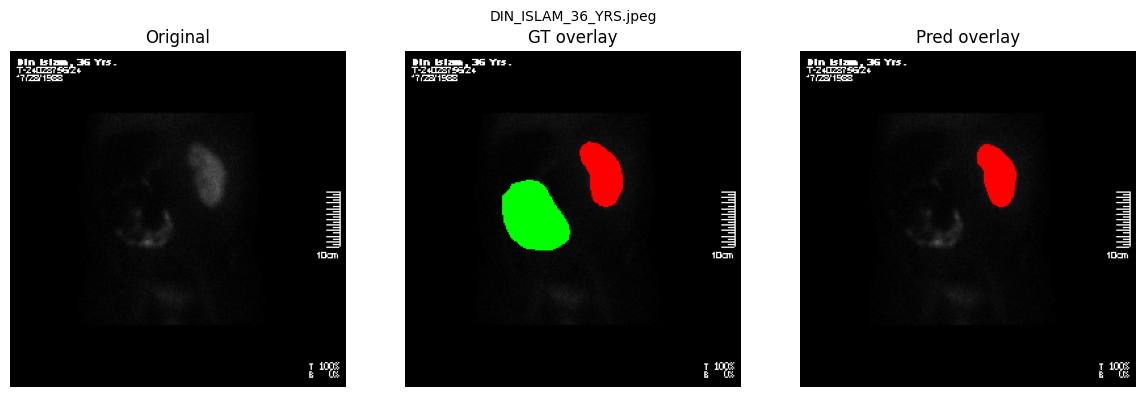

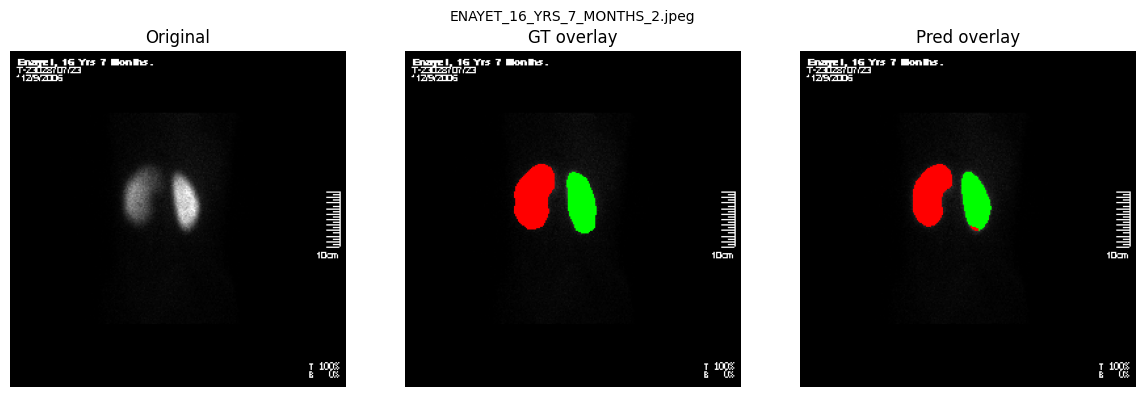

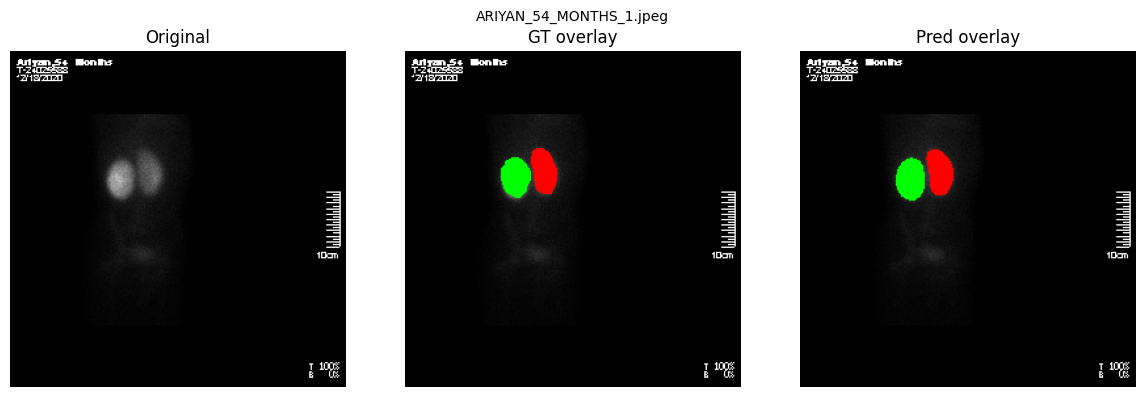

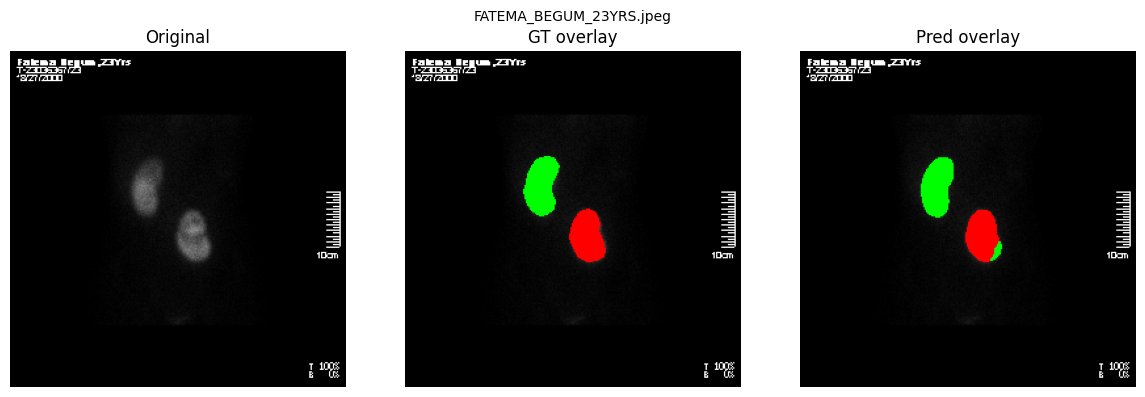

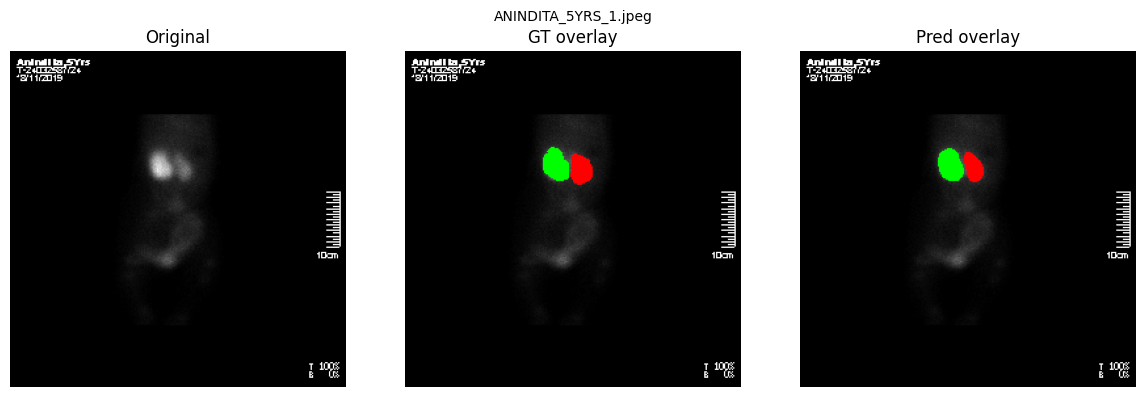

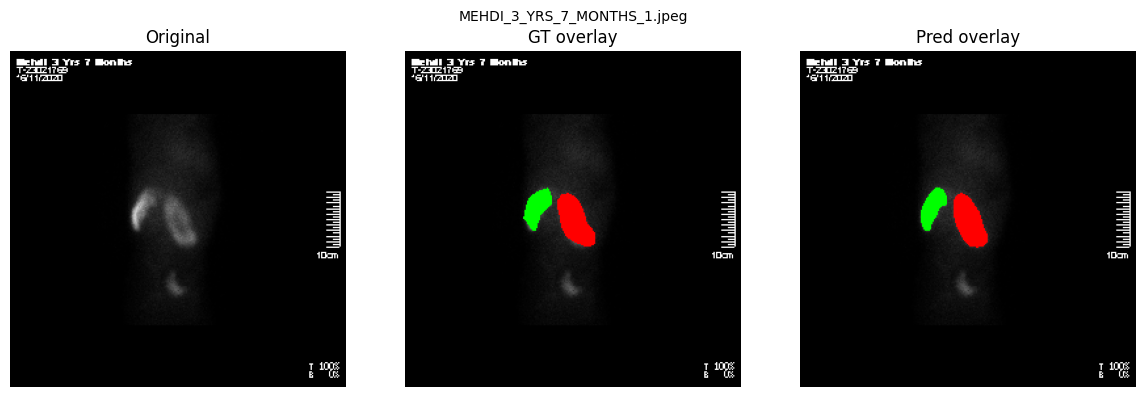

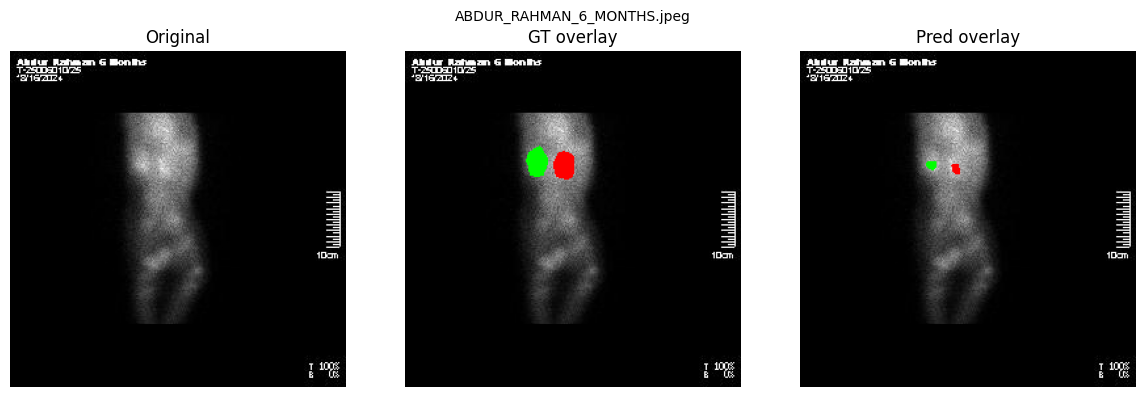

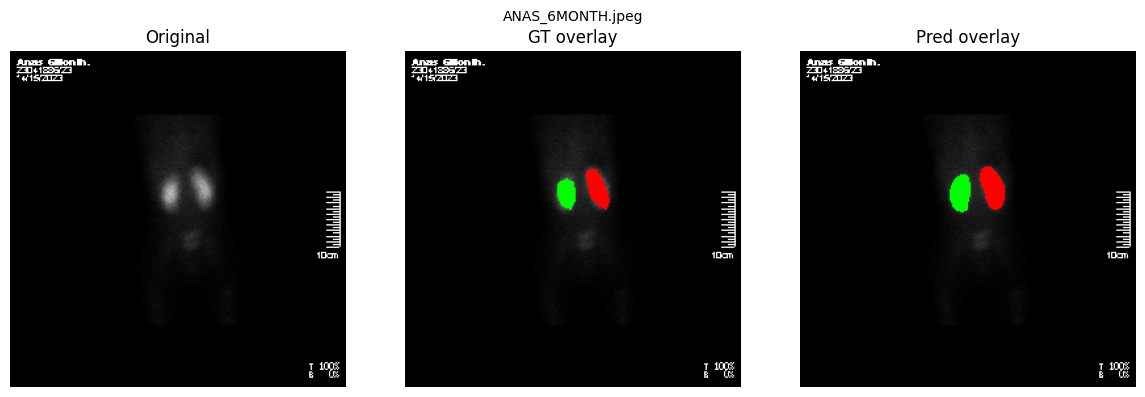

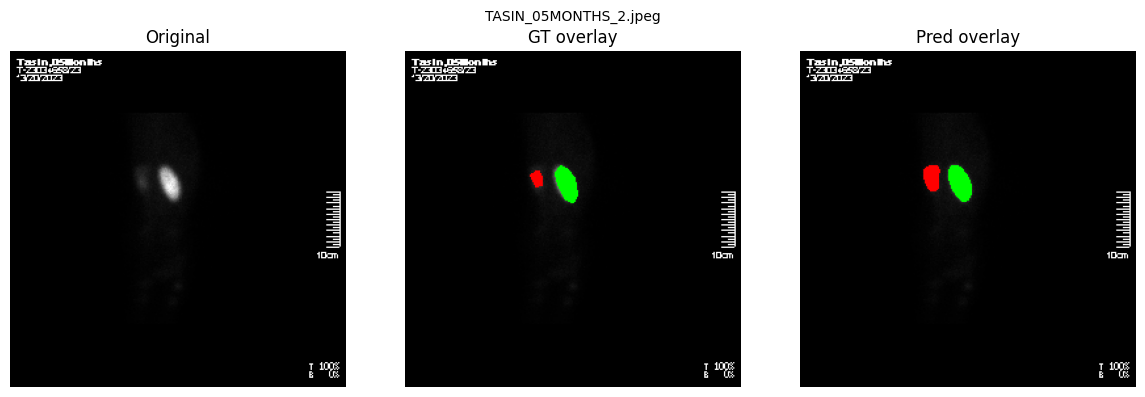

In [16]:
# CELL 13 — FULL REPLACEMENT
# Visual QC on validation (GT vs Pred) — rerun anytime

def show_pred_samples(n=10):
    model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
    model.eval()

    # pick random val indices
    idxs = list(range(len(val_ds)))
    random.shuffle(idxs)
    idxs = idxs[:min(n, len(idxs))]

    for idx in idxs:
        x, y, base = val_ds[idx]
        with torch.no_grad():
            logits = model(x.unsqueeze(0).to(device))
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        img = (x.squeeze(0).numpy())
        img = (img - img.min()) / (img.max() - img.min() + 1e-6)
        img_u8 = (img * 255).astype(np.uint8)

        gt = y.numpy()

        # overlays
        overlay_pred = np.stack([img_u8,img_u8,img_u8], axis=-1)
        overlay_gt   = np.stack([img_u8,img_u8,img_u8], axis=-1)

        # LEFT green, RIGHT red
        overlay_pred[pred==1] = (0,255,0)
        overlay_pred[pred==2] = (255,0,0)
        overlay_gt[gt==1]     = (0,255,0)
        overlay_gt[gt==2]     = (255,0,0)

        fig, ax = plt.subplots(1,3, figsize=(12,4))
        ax[0].imshow(img_u8, cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
        ax[1].imshow(overlay_gt); ax[1].set_title("GT overlay"); ax[1].axis("off")
        ax[2].imshow(overlay_pred); ax[2].set_title("Pred overlay"); ax[2].axis("off")
        plt.suptitle(base, fontsize=10)
        plt.tight_layout()
        plt.show()

show_pred_samples(n=10)


In [17]:
# CELL 14 — FULL REPLACEMENT
# Inference: generate masks for ALL patients (all CSV rows)
# Saves PNG masks (0/1/2) using CSV LINK basename.
# NOTE: No new CSV columns are added. Output is a folder of mask images.

model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
model.eval()

out_mask_dir = os.path.join(OUT_DIR, "pred_masks_png")
os.makedirs(out_mask_dir, exist_ok=True)

def save_mask_png(mask_u8, out_path):
    # mask_u8: HxW uint8 {0,1,2}
    Image.fromarray(mask_u8, mode="L").save(out_path)

done = 0
failed = 0

for i in range(len(df)):
    row = df.iloc[i]
    base = row["_BASENAME"]
    try:
        path = resolve_image_path_from_csv_row(row)
        img = load_image_gray256(path).astype(np.float32)/255.0
        img = (img - img.mean())/(img.std()+1e-6)
        x = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

        out_path = os.path.join(out_mask_dir, base.replace(".jpeg","").replace(".jpg","") + "_mask.png")
        save_mask_png(pred, out_path)
        done += 1
    except Exception as e:
        failed += 1

print("Saved masks:", done)
print("Failed:", failed)
print("Output folder:", out_mask_dir)


C:\Users\User\AppData\Local\Temp\ipykernel_2332\3791027437.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_CKPT, map_location=devic

Saved masks: 2294
Failed: 0
Output folder: ./phase4a_seg_outputs\pred_masks_png


In [18]:
# CELL 15 — ADD NEW CELL
# Total accuracy report (Left / Right / Overall) on validation set
# Definitions:
# - overall_pixel_acc: (pred == gt) over ALL pixels
# - left_pixel_acc: binary pixel accuracy for class-1 (left vs not-left)
# - right_pixel_acc: binary pixel accuracy for class-2 (right vs not-right)
# Also prints Dice and IoU for left/right (more meaningful for segmentation).

def iou_per_class(pred, target, cls, eps=1e-6):
    p = (pred == cls).astype(np.uint8)
    t = (target == cls).astype(np.uint8)
    inter = (p & t).sum()
    union = (p | t).sum()
    return float((inter + eps) / (union + eps))

@torch.no_grad()
def segmentation_accuracy_report():
    # Load best model
    model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
    model.eval()

    total_pixels = 0
    correct_pixels = 0

    # binary accuracies for left/right
    total_left = 0
    correct_left = 0
    total_right = 0
    correct_right = 0

    dices_L = []
    dices_R = []
    ious_L = []
    ious_R = []

    for x, y, _base in val_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)  # BxHxW

        logits = model(x)
        pred = torch.argmax(logits, dim=1)  # BxHxW

        pred_np = pred.cpu().numpy()
        y_np = y.cpu().numpy()

        # overall pixel accuracy
        total_pixels += y_np.size
        correct_pixels += (pred_np == y_np).sum()

        # left/right binary pixel accuracy
        # left: class 1 vs not-1
        pL = (pred_np == 1)
        gL = (y_np == 1)
        total_left += gL.size
        correct_left += (pL == gL).sum()

        # right: class 2 vs not-2
        pR = (pred_np == 2)
        gR = (y_np == 2)
        total_right += gR.size
        correct_right += (pR == gR).sum()

        # Dice + IoU per image
        for i in range(pred_np.shape[0]):
            dices_L.append(dice_per_class(pred_np[i], y_np[i], 1))
            dices_R.append(dice_per_class(pred_np[i], y_np[i], 2))
            ious_L.append(iou_per_class(pred_np[i], y_np[i], 1))
            ious_R.append(iou_per_class(pred_np[i], y_np[i], 2))

    overall_pixel_acc = correct_pixels / max(1, total_pixels)
    left_pixel_acc = correct_left / max(1, total_left)
    right_pixel_acc = correct_right / max(1, total_right)

    print("===== SEGMENTATION ACCURACY (VALIDATION) =====")
    print(f"Overall pixel accuracy: {overall_pixel_acc:.4f}")
    print(f"Left kidney pixel accuracy (class-1 vs rest): {left_pixel_acc:.4f}")
    print(f"Right kidney pixel accuracy (class-2 vs rest): {right_pixel_acc:.4f}")
    print("")
    print("===== SEGMENTATION QUALITY (MORE MEANINGFUL THAN PIXEL ACC) =====")
    print(f"Left Dice:  mean={float(np.mean(dices_L)):.4f} | median={float(np.median(dices_L)):.4f}")
    print(f"Right Dice: mean={float(np.mean(dices_R)):.4f} | median={float(np.median(dices_R)):.4f}")
    print(f"Left IoU:   mean={float(np.mean(ious_L)):.4f} | median={float(np.median(ious_L)):.4f}")
    print(f"Right IoU:  mean={float(np.mean(ious_R)):.4f} | median={float(np.median(ious_R)):.4f}")
    print("=============================================")

segmentation_accuracy_report()


C:\Users\User\AppData\Local\Temp\ipykernel_2332\656331918.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_CKPT, map_location=devic

===== SEGMENTATION ACCURACY (VALIDATION) =====
Overall pixel accuracy: 0.9961
Left kidney pixel accuracy (class-1 vs rest): 0.9976
Right kidney pixel accuracy (class-2 vs rest): 0.9977

===== SEGMENTATION QUALITY (MORE MEANINGFUL THAN PIXEL ACC) =====
Left Dice:  mean=0.8412 | median=0.9164
Right Dice: mean=0.7934 | median=0.9111
Left IoU:   mean=0.7729 | median=0.8457
Right IoU:  mean=0.7267 | median=0.8367


In [19]:
# CELL 16 — ADD NEW CELL
# Confusion Matrix + Precision/Recall/F1 (pixel-level, 3-class: 0=BG, 1=LEFT, 2=RIGHT)

import numpy as np
import torch

@torch.no_grad()
def segmentation_confusion_matrix_report(normalize: bool = True):
    # Load best model
    model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
    model.eval()

    # Confusion matrix rows=GT, cols=PRED
    # classes: 0=BG, 1=LEFT, 2=RIGHT
    cm = np.zeros((3, 3), dtype=np.int64)

    for x, y, _base in val_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)          # BxHxW (0/1/2)

        logits = model(x)
        pred = torch.argmax(logits, dim=1)           # BxHxW

        gt = y.view(-1).cpu().numpy()
        pr = pred.view(-1).cpu().numpy()

        # update cm
        for g, p in zip(gt, pr):
            if 0 <= g <= 2 and 0 <= p <= 2:
                cm[g, p] += 1

    print("===== PIXEL CONFUSION MATRIX (VAL) =====")
    print("rows=GT, cols=PRED | classes: 0=BG, 1=LEFT, 2=RIGHT")
    print(cm)

    if normalize:
        cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        print("\n===== NORMALIZED (per GT row) =====")
        print(np.round(cm_norm, 4))

    # Per-class precision/recall/f1
    print("\n===== PER-CLASS METRICS (PIXEL-LEVEL) =====")
    for c in range(3):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        prec = tp / max(1, (tp + fp))
        rec  = tp / max(1, (tp + fn))
        f1   = (2 * prec * rec) / max(1e-12, (prec + rec))

        name = {0: "BG", 1: "LEFT", 2: "RIGHT"}[c]
        print(f"{name:5s}: precision={prec:.4f} | recall={rec:.4f} | f1={f1:.4f}")

    overall_acc = np.trace(cm) / max(1, cm.sum())
    print(f"\nOverall pixel accuracy (from CM): {overall_acc:.4f}")
    print("=========================================")

segmentation_confusion_matrix_report(normalize=True)


C:\Users\User\AppData\Local\Temp\ipykernel_2332\885197070.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_CKPT, map_location=devic

===== PIXEL CONFUSION MATRIX (VAL) =====
rows=GT, cols=PRED | classes: 0=BG, 1=LEFT, 2=RIGHT
[[31537720    17270    19050]
 [   34904   208347     9139]
 [   30710    14531   175433]]

===== NORMALIZED (per GT row) =====
[[9.988e-01 5.000e-04 6.000e-04]
 [1.383e-01 8.255e-01 3.620e-02]
 [1.392e-01 6.580e-02 7.950e-01]]

===== PER-CLASS METRICS (PIXEL-LEVEL) =====
BG   : precision=0.9979 | recall=0.9988 | f1=0.9984
LEFT : precision=0.8676 | recall=0.8255 | f1=0.8460
RIGHT: precision=0.8616 | recall=0.7950 | f1=0.8269

Overall pixel accuracy (from CM): 0.9961


Saved: C:\Users\User\Downloads\phase4a_stepB_train_segmentation_unet (1).seg_losses.csv


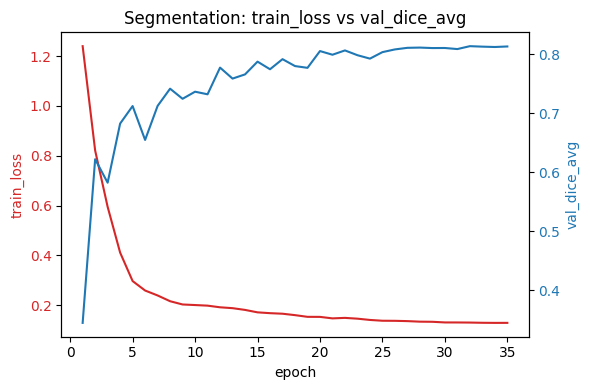

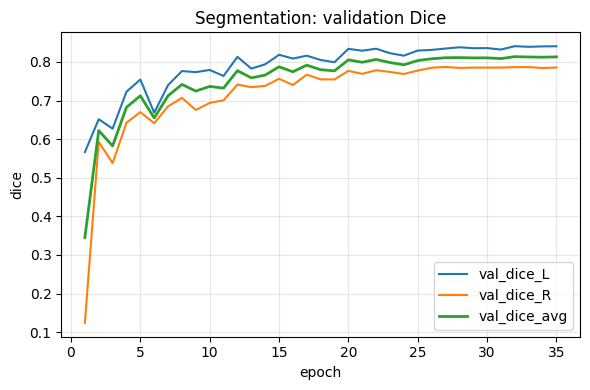

In [21]:
import json, re, math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

NB_PATH = Path(r"C:\Users\User\Downloads\phase4a_stepB_train_segmentation_unet (1).ipynb")

nb = json.loads(NB_PATH.read_text(encoding="utf-8"))

lines = []
for cell in nb.get("cells", []):
    for out in cell.get("outputs", []):
        text = ""
        if "text" in out:
            t = out["text"]
            text = "".join(t) if isinstance(t, list) else str(t)
        elif isinstance(out.get("data"), dict) and "text/plain" in out["data"]:
            t = out["data"]["text/plain"]
            text = "".join(t) if isinstance(t, list) else str(t)
        if text:
            lines.extend(text.splitlines())

pat = re.compile(
    r"Epoch\s+(\d+)\s+\|\s+train_loss=([0-9.]+)\s+\|\s+val_dice_L=([0-9.]+)\s+val_dice_R=([0-9.]+)\s+val_dice_avg=([0-9.]+)"
)

rows = []
for line in lines:
    m = pat.search(line)
    if m:
        ep = int(m.group(1))
        rows.append({
            "epoch": ep,
            "train_loss": float(m.group(2)),
            "val_dice_L": float(m.group(3)),
            "val_dice_R": float(m.group(4)),
            "val_dice_avg": float(m.group(5)),
        })

df = pd.DataFrame(rows).sort_values("epoch")
if df.empty:
    print("No epoch logs found in outputs. (Maybe outputs were cleared?)")
else:
    out_csv = NB_PATH.with_suffix(".seg_losses.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    fig, ax1 = plt.subplots(figsize=(6,4))
    ax1.plot(df["epoch"], df["train_loss"], color="tab:red", label="train_loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("train_loss", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax2 = ax1.twinx()
    ax2.plot(df["epoch"], df["val_dice_avg"], color="tab:blue", label="val_dice_avg")
    ax2.set_ylabel("val_dice_avg", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    plt.title("Segmentation: train_loss vs val_dice_avg")
    fig.tight_layout()
    plt.show()

    # Optional: separate plot for L/R dice
    plt.figure(figsize=(6,4))
    plt.plot(df["epoch"], df["val_dice_L"], label="val_dice_L")
    plt.plot(df["epoch"], df["val_dice_R"], label="val_dice_R")
    plt.plot(df["epoch"], df["val_dice_avg"], label="val_dice_avg", linewidth=2)
    plt.xlabel("epoch"); plt.ylabel("dice")
    plt.title("Segmentation: validation Dice")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [23]:
def run_eval(model, loader):
    model.eval()
    dices_L, dices_R = [], []
    total = 0.0
    nb = 0
    with torch.no_grad():
        for x, y, _base in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)

            # val loss
            loss = total_loss(logits, y)
            total += float(loss.item())
            nb += 1

            pred = torch.argmax(logits, dim=1).cpu().numpy()
            gt   = y.cpu().numpy()
            for i in range(pred.shape[0]):
                dices_L.append(dice_per_class(pred[i], gt[i], 1))
                dices_R.append(dice_per_class(pred[i], gt[i], 2))

    val_loss = total / max(1, nb)
    return val_loss, float(np.mean(dices_L)), float(np.mean(dices_R)), float(np.mean(dices_L + dices_R))
val_loss, val_dL, val_dR, val_dAvg = run_eval(model, val_loader)
print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_dice_L={val_dL:.4f} val_dice_R={val_dR:.4f} val_dice_avg={val_dAvg:.4f}")


Epoch 35 | train_loss=0.1313 | val_loss=0.1434 | val_dice_L=0.8412 val_dice_R=0.7934 val_dice_avg=0.8173
